# Welcome to Colab!

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

## Google Colab is available in VS Code!
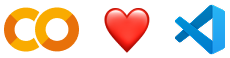

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



DOWNLOADING MNIST DATASET
MNIST dataset loaded successfully
Test images: (10000, 28, 28)
Test labels: (10000,)
Prepared test data: (10000, 28, 28, 1)

DOWNLOADING PRE-TRAINED CNN MODEL


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Pre-trained model downloaded successfully

Searching for saved model files...
Model path: /content/pretrained_mnist_cnn

Loading pre-trained model...
Model loaded successfully
Available signatures: ['serving_default']

Model input:
((), {'input_1': TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_1')})

Model output:
{'dense': TensorSpec(shape=(None, 10), dtype=tf.float32, name='dense')}

Input name: input_1
Output name: dense

PREDICTING MNIST TEST DATA

MNIST TEST ACCURACY:
98.99%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9879    0.9969    0.9924       980
           1     0.9939    0.9974    0.9956      1135
           2     0.9912    0.9845    0.9878      1032
           3     0.9930    0.9881    0.9906      1010
           4     0.9949    0.9949    0.9949       982
           5     0.9811    0.9910    0.9861       892
           6     0.9916    0.9885    0.9901       958
           7     0.9836    0.9912    0.

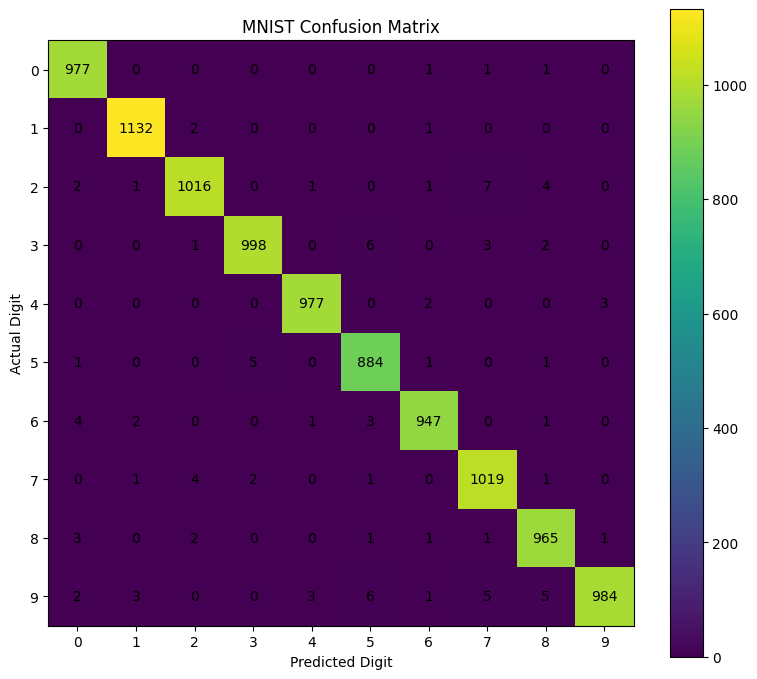


Results saved as:
/content/handwritten_results.csv


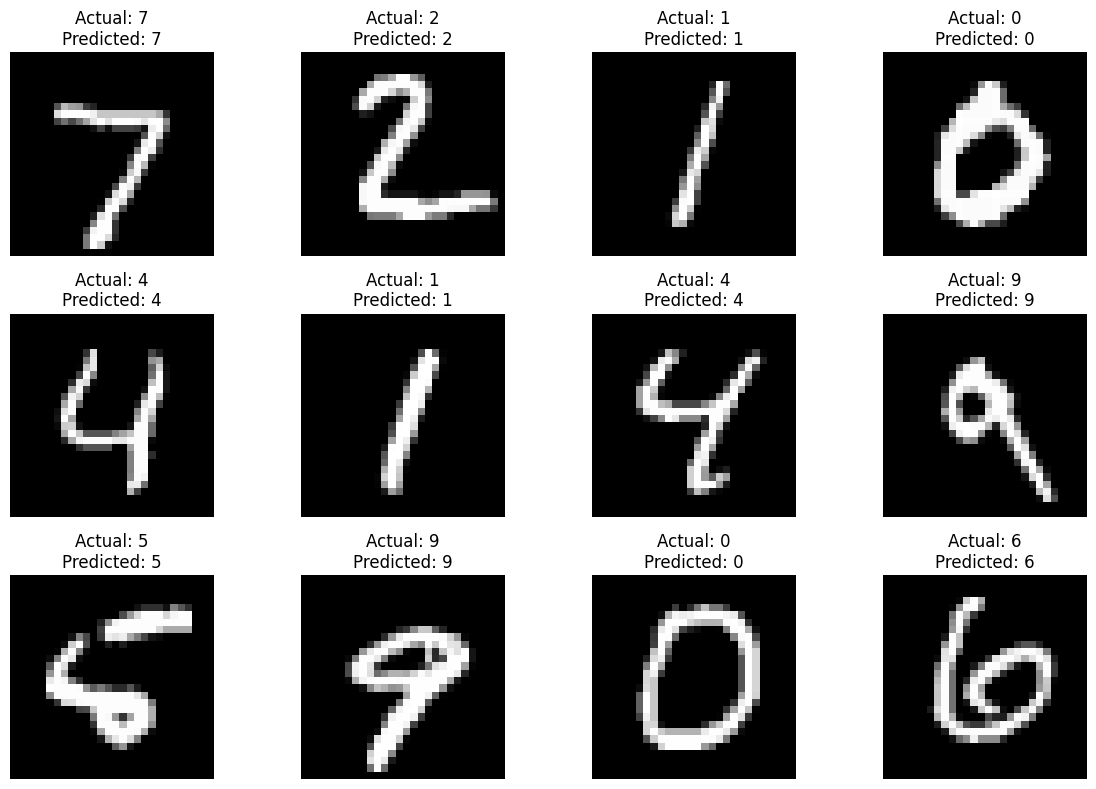

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


UPLOAD YOUR HANDWRITTEN DIGIT
Upload an image containing ONE handwritten digit.


Saving Number_2.jpeg to Number_2 (3).jpeg

Uploaded file:
Number_2 (3).jpeg
Original image size: (1038, 1068)


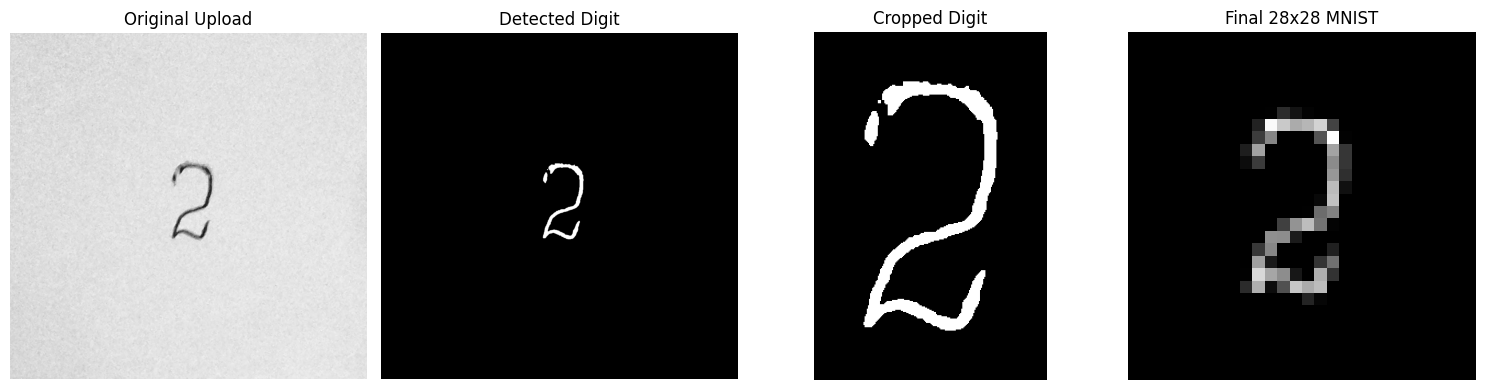


Final model input shape: (1, 28, 28, 1)

CUSTOM IMAGE PREDICTION
Digit 0: 0.71%
Digit 1: 0.20%
Digit 2: 62.78%
Digit 3: 27.50%
Digit 4: 0.00%
Digit 5: 0.10%
Digit 6: 0.01%
Digit 7: 5.85%
Digit 8: 1.14%
Digit 9: 1.71%

PREDICTED DIGIT: 2
CONFIDENCE: 62.78%


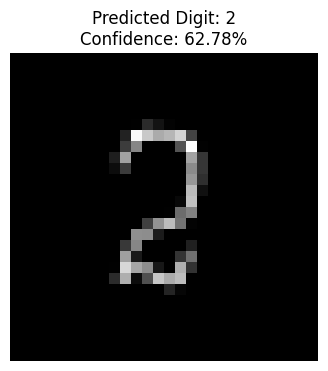


Custom prediction added to:
/content/handwritten_results.csv

Processed 28x28 image saved as:
/content/processed_handwritten_digit.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


PROJECT COMPLETED
✓ MNIST dataset loaded
✓ Pre-trained CNN model loaded
✓ MNIST test predictions generated
✓ Accuracy calculated
✓ Classification report generated
✓ Confusion matrix generated
✓ Custom image uploaded
✓ Digit automatically detected
✓ Background automatically removed
✓ Digit cropped
✓ Digit resized
✓ Digit centered
✓ Custom digit predicted
✓ Results saved to handwritten_results.csv


In [4]:
# ============================================================
# TASK 3: HANDWRITTEN CHARACTER RECOGNITION
# Pre-trained CNN Model
# Dataset: MNIST
# Google Colab
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install huggingface_hub opencv-python-headless joblib pandas numpy matplotlib scikit-learn


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from google.colab import files
from huggingface_hub import snapshot_download
from sklearn.metrics import classification_report, confusion_matrix


# ============================================================
# 3. LOAD MNIST DATASET
# ============================================================

print("=" * 60)
print("DOWNLOADING MNIST DATASET")
print("=" * 60)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("MNIST dataset loaded successfully")
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)


# ============================================================
# 4. PREPARE MNIST TEST DATA
# ============================================================

x_test_normalized = x_test.astype("float32") / 255.0

# Add channel dimension
x_test_normalized = np.expand_dims(x_test_normalized, axis=-1)

print("Prepared test data:", x_test_normalized.shape)


# ============================================================
# 5. DOWNLOAD PRE-TRAINED MODEL
# ============================================================

print("\n" + "=" * 60)
print("DOWNLOADING PRE-TRAINED CNN MODEL")
print("=" * 60)

MODEL_REPO = "keras-io/simple-mnist-convnet"
MODEL_DIR = "/content/pretrained_mnist_cnn"

snapshot_download(
    repo_id=MODEL_REPO,
    local_dir=MODEL_DIR
)

print("Pre-trained model downloaded successfully")


# ============================================================
# 6. FIND SAVED MODEL
# ============================================================

print("\nSearching for saved model files...")

model_path = None

for root, dirs, files_list in os.walk(MODEL_DIR):
    for file_name in files_list:

        full_path = os.path.join(root, file_name)

        if file_name == "saved_model.pb":
            model_path = root
            break

    if model_path is not None:
        break

print("Model path:", model_path)


# ============================================================
# 7. LOAD PRE-TRAINED MODEL
# ============================================================

print("\nLoading pre-trained model...")

model = tf.saved_model.load(model_path)

print("Model loaded successfully")


# ============================================================
# 8. GET MODEL SIGNATURE
# ============================================================

signatures = list(model.signatures.keys())

print("Available signatures:", signatures)

infer = model.signatures["serving_default"]

print("\nModel input:")
print(infer.structured_input_signature)

print("\nModel output:")
print(infer.structured_outputs)


# ============================================================
# 9. DETECT INPUT AND OUTPUT NAMES
# ============================================================

input_name = list(infer.structured_input_signature[1].keys())[0]
output_name = list(infer.structured_outputs.keys())[0]

print("\nInput name:", input_name)
print("Output name:", output_name)


# ============================================================
# 10. PREDICT MNIST TEST DATA
# ============================================================

print("\n" + "=" * 60)
print("PREDICTING MNIST TEST DATA")
print("=" * 60)

batch_size = 256
all_predictions = []
all_confidences = []

for start in range(0, len(x_test_normalized), batch_size):

    end = start + batch_size

    batch = x_test_normalized[start:end]

    output = infer(
        **{
            input_name: tf.constant(batch, dtype=tf.float32)
        }
    )

    prediction_output = output[output_name].numpy()

    # Convert logits to probabilities if necessary
    if prediction_output.min() < 0 or prediction_output.max() > 1:
        prediction_output = tf.nn.softmax(
            prediction_output,
            axis=1
        ).numpy()

    predictions = np.argmax(
        prediction_output,
        axis=1
    )

    confidences = np.max(
        prediction_output,
        axis=1
    )

    all_predictions.extend(predictions)
    all_confidences.extend(confidences)


all_predictions = np.array(all_predictions)
all_confidences = np.array(all_confidences)


# ============================================================
# 11. CALCULATE ACCURACY
# ============================================================

accuracy = np.mean(all_predictions == y_test)

print("\nMNIST TEST ACCURACY:")
print(f"{accuracy * 100:.2f}%")


# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        all_predictions,
        digits=4
    )
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    all_predictions
)

plt.figure(figsize=(8, 7))

plt.imshow(cm)

plt.title("MNIST Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ============================================================
# 14. SAVE MNIST RESULTS
# ============================================================

results_df = pd.DataFrame({
    "Actual_Digit": y_test,
    "Predicted_Digit": all_predictions,
    "Confidence": all_confidences
})

CSV_PATH = "/content/handwritten_results.csv"

results_df.to_csv(
    CSV_PATH,
    index=False
)

print("\nResults saved as:")
print(CSV_PATH)


# ============================================================
# 15. SHOW SAMPLE MNIST PREDICTIONS
# ============================================================

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        x_test[i],
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[i]}\n"
        f"Predicted: {all_predictions[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 16. DOWNLOAD MNIST RESULTS CSV
# ============================================================

files.download(CSV_PATH)


# ============================================================
# 17. UPLOAD YOUR OWN HANDWRITTEN DIGIT
# ============================================================

print("\n" + "=" * 60)
print("UPLOAD YOUR HANDWRITTEN DIGIT")
print("=" * 60)

print(
    "Upload an image containing ONE handwritten digit."
)

uploaded = files.upload()


# Get uploaded filename
uploaded_filename = list(uploaded.keys())[0]

print("\nUploaded file:")
print(uploaded_filename)


# ============================================================
# 18. READ UPLOADED IMAGE
# ============================================================

original_image = cv2.imread(
    uploaded_filename,
    cv2.IMREAD_GRAYSCALE
)

if original_image is None:
    raise ValueError(
        "Could not read the uploaded image."
    )

print(
    "Original image size:",
    original_image.shape
)


# ============================================================
# 19. IMPROVE IMAGE
# ============================================================

# Resize only if image is extremely small
if original_image.shape[0] < 50 or original_image.shape[1] < 50:

    scale = 4

    original_image = cv2.resize(
        original_image,
        None,
        fx=scale,
        fy=scale,
        interpolation=cv2.INTER_CUBIC
    )


# Slight blur removes tiny camera noise
blurred = cv2.GaussianBlur(
    original_image,
    (5, 5),
    0
)


# ============================================================
# 20. AUTOMATICALLY DETECT DIGIT
# ============================================================

# Otsu threshold with inversion
binary = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)[1]


# ============================================================
# 21. REMOVE SMALL NOISE
# ============================================================

kernel = np.ones(
    (3, 3),
    np.uint8
)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)


# Close small gaps in handwritten strokes
binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1
)


# ============================================================
# 22. FIND CONTOURS
# ============================================================

contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


# ============================================================
# 23. SELECT THE DIGIT CONTOUR
# ============================================================

image_height, image_width = binary.shape

image_area = image_height * image_width

valid_contours = []

for contour in contours:

    area = cv2.contourArea(contour)

    x, y, w, h = cv2.boundingRect(contour)

    # Ignore extremely tiny noise
    if area < image_area * 0.0005:
        continue

    # Ignore objects touching almost the entire image
    if w > image_width * 0.95 and h > image_height * 0.95:
        continue

    valid_contours.append(
        (area, contour)
    )


if len(valid_contours) == 0:

    print("\nWARNING: No contour detected.")
    print("Trying automatic pixel detection...")

    # Fallback method
    ys, xs = np.where(binary > 0)

    if len(xs) == 0:

        raise ValueError(
            "No handwritten digit could be detected. "
            "Please upload a clearer image with one digit."
        )

    x1 = max(0, xs.min() - 5)
    x2 = min(binary.shape[1], xs.max() + 6)

    y1 = max(0, ys.min() - 5)
    y2 = min(binary.shape[0], ys.max() + 6)

else:

    # Largest meaningful contour
    valid_contours.sort(
        key=lambda z: z[0],
        reverse=True
    )

    largest_area, largest_contour = valid_contours[0]

    x, y, w, h = cv2.boundingRect(
        largest_contour
    )

    # Extra padding
    padding_x = max(
        10,
        int(w * 0.20)
    )

    padding_y = max(
        10,
        int(h * 0.20)
    )

    x1 = max(
        0,
        x - padding_x
    )

    y1 = max(
        0,
        y - padding_y
    )

    x2 = min(
        binary.shape[1],
        x + w + padding_x
    )

    y2 = min(
        binary.shape[0],
        y + h + padding_y
    )


# ============================================================
# 24. CROP DETECTED DIGIT
# ============================================================

digit_crop = binary[
    y1:y2,
    x1:x2
]


# ============================================================
# 25. REMOVE EMPTY BORDER FROM CROP
# ============================================================

ys, xs = np.where(
    digit_crop > 0
)

if len(xs) > 0:

    crop_x1 = xs.min()
    crop_x2 = xs.max() + 1

    crop_y1 = ys.min()
    crop_y2 = ys.max() + 1

    digit_crop = digit_crop[
        crop_y1:crop_y2,
        crop_x1:crop_x2
    ]


# ============================================================
# 26. ADD PADDING
# ============================================================

h, w = digit_crop.shape

padding = int(
    max(h, w) * 0.20
)

digit_crop = cv2.copyMakeBorder(
    digit_crop,
    padding,
    padding,
    padding,
    padding,
    cv2.BORDER_CONSTANT,
    value=0
)


# ============================================================
# 27. RESIZE DIGIT WITHOUT DISTORTION
# ============================================================

h, w = digit_crop.shape

target_digit_size = 20

scale = target_digit_size / max(
    h,
    w
)

new_w = max(
    1,
    int(round(w * scale))
)

new_h = max(
    1,
    int(round(h * scale))
)

resized_digit = cv2.resize(
    digit_crop,
    (new_w, new_h),
    interpolation=cv2.INTER_AREA
)


# ============================================================
# 28. CREATE MNIST 28x28 CANVAS
# ============================================================

mnist_image = np.zeros(
    (28, 28),
    dtype=np.uint8
)


# Put digit initially in center
start_x = (28 - new_w) // 2
start_y = (28 - new_h) // 2

mnist_image[
    start_y:start_y + new_h,
    start_x:start_x + new_w
] = resized_digit


# ============================================================
# 29. CENTER DIGIT USING CENTER OF MASS
# ============================================================

moments = cv2.moments(
    mnist_image
)

if moments["m00"] != 0:

    center_x = (
        moments["m10"] /
        moments["m00"]
    )

    center_y = (
        moments["m01"] /
        moments["m00"]
    )

    desired_x = 13.5
    desired_y = 13.5

    shift_x = int(
        round(desired_x - center_x)
    )

    shift_y = int(
        round(desired_y - center_y)
    )

    # Affine translation
    translation_matrix = np.float32([
        [1, 0, shift_x],
        [0, 1, shift_y]
    ])

    mnist_image = cv2.warpAffine(
        mnist_image,
        translation_matrix,
        (28, 28),
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )


# ============================================================
# 30. FINAL CLEANUP
# ============================================================

# Make sure values are between 0 and 255
mnist_image = np.clip(
    mnist_image,
    0,
    255
).astype(np.uint8)


# ============================================================
# 31. DISPLAY PROCESSING
# ============================================================

plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)

plt.imshow(
    original_image,
    cmap="gray"
)

plt.title("Original Upload")
plt.axis("off")


plt.subplot(1, 4, 2)

plt.imshow(
    binary,
    cmap="gray"
)

plt.title("Detected Digit")
plt.axis("off")


plt.subplot(1, 4, 3)

plt.imshow(
    digit_crop,
    cmap="gray"
)

plt.title("Cropped Digit")
plt.axis("off")


plt.subplot(1, 4, 4)

plt.imshow(
    mnist_image,
    cmap="gray"
)

plt.title("Final 28x28 MNIST")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 32. PREPARE IMAGE FOR MODEL
# ============================================================

custom_image = (
    mnist_image.astype("float32") /
    255.0
)

custom_image = np.expand_dims(
    custom_image,
    axis=0
)

custom_image = np.expand_dims(
    custom_image,
    axis=-1
)

print(
    "\nFinal model input shape:",
    custom_image.shape
)


# ============================================================
# 33. PREDICT CUSTOM DIGIT
# ============================================================

custom_output = infer(
    **{
        input_name:
        tf.constant(
            custom_image,
            dtype=tf.float32
        )
    }
)

custom_prediction = (
    custom_output[output_name]
    .numpy()
)


# ============================================================
# 34. CONVERT TO PROBABILITIES
# ============================================================

if (
    custom_prediction.min() < 0
    or custom_prediction.max() > 1
):

    custom_probabilities = tf.nn.softmax(
        custom_prediction,
        axis=1
    ).numpy()[0]

else:

    custom_probabilities = (
        custom_prediction[0]
    )


# ============================================================
# 35. GET PREDICTED DIGIT
# ============================================================

predicted_digit = int(
    np.argmax(
        custom_probabilities
    )
)

confidence = float(
    np.max(
        custom_probabilities
    )
)


# ============================================================
# 36. DISPLAY PROBABILITIES
# ============================================================

print("\n" + "=" * 60)
print("CUSTOM IMAGE PREDICTION")
print("=" * 60)

for digit in range(10):

    print(
        f"Digit {digit}: "
        f"{custom_probabilities[digit] * 100:.2f}%"
    )


print("\n" + "=" * 60)

print(
    f"PREDICTED DIGIT: {predicted_digit}"
)

print(
    f"CONFIDENCE: {confidence * 100:.2f}%"
)

print("=" * 60)


# ============================================================
# 37. SHOW FINAL PREDICTION
# ============================================================

plt.figure(figsize=(4, 4))

plt.imshow(
    mnist_image,
    cmap="gray"
)

plt.title(
    f"Predicted Digit: {predicted_digit}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()


# ============================================================
# 38. SAVE CUSTOM RESULT
# ============================================================

custom_result = pd.DataFrame({
    "Image_Name": [uploaded_filename],
    "Predicted_Digit": [predicted_digit],
    "Confidence": [confidence]
})

# Same requested CSV name
custom_result.to_csv(
    CSV_PATH,
    mode="a",
    header=False,
    index=False
)

print(
    "\nCustom prediction added to:"
)

print(
    CSV_PATH
)


# ============================================================
# 39. SAVE PROCESSED IMAGE
# ============================================================

processed_image_path = (
    "/content/processed_handwritten_digit.png"
)

cv2.imwrite(
    processed_image_path,
    mnist_image
)

print(
    "\nProcessed 28x28 image saved as:"
)

print(
    processed_image_path
)


# ============================================================
# 40. DOWNLOAD FINAL CSV
# ============================================================

print(
    "\nDownloading handwritten_results.csv..."
)

files.download(
    CSV_PATH
)


# ============================================================
# 41. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

print("✓ MNIST dataset loaded")
print("✓ Pre-trained CNN model loaded")
print("✓ MNIST test predictions generated")
print("✓ Accuracy calculated")
print("✓ Classification report generated")
print("✓ Confusion matrix generated")
print("✓ Custom image uploaded")
print("✓ Digit automatically detected")
print("✓ Background automatically removed")
print("✓ Digit cropped")
print("✓ Digit resized")
print("✓ Digit centered")
print("✓ Custom digit predicted")
print("✓ Results saved to handwritten_results.csv")
print("=" * 60)

In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  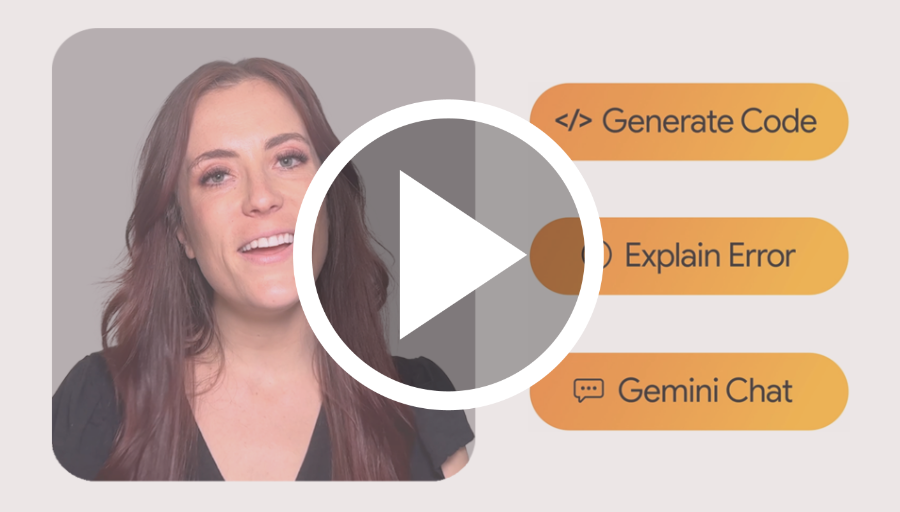
  </a>
</center>

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

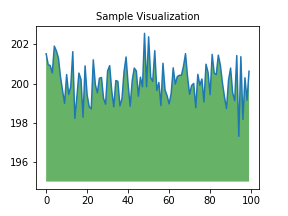

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
